# DSC-515 Analyzing Social Media Networks using Python

## Overview 
This project examines a social network by constructing a graph from interaction data and analyzing its structure through metrics like centrality, clustering, and community patterns. It highlights key influencers, visualizes how users connect, and interprets how information might spread across the network. The work concludes with a written discussion translating these findings into practical insights for shaping an effective social media strategy.

## Preprocessing
Load the necessary libraries.

In [ ]:
# Load libraries
import janitor
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

The email dataset captures 112 days of real email traffic at the University of Kiel, where each node is an email address and each directed edge represents at least one message sent from one address to another. It reflects a real-world communication network with scale‑free properties.

In [3]:
# Load the graph object from the edgelist file
G = nx.read_edgelist(
    r"C:\Users\tdjoh\OneDrive\Desktop\Data Modeling\Week 7\Data\email.edgelist.txt",
    create_using=nx.DiGraph()
)

# Inspect the data
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Sample edges: {list(G.edges())[:10]}")

Number of nodes: 57194
Number of edges: 103731
Sample edges: [('0', '0'), ('1', '1'), ('1', '63'), ('1', '144'), ('1', '196'), ('1', '384'), ('1', '10589'), ('1', '14267'), ('1', '14706'), ('1', '23186')]


In [4]:
# Check for missing values and duplicates
edges_df = pd.DataFrame(G.edges(), columns=['source', 'target'])
print("Missing values in edges:", edges_df.isnull().sum())
print("Duplicate edges:", edges_df.duplicated().sum())

Missing values in edges: source    0
target    0
dtype: int64
Duplicate edges: 0


Validate the raw edgelist (G).

In [ ]:
# Check for nodes with no edges
isolated_nodes = list(nx.isolates(G))
if isolated_nodes:
    print(f"Isolated nodes (no edges): {isolated_nodes}")
else:
    print("No isolated nodes found.")

# Confirm that all edges are valid (both nodes exist in the graph)
invalid_edges = [(u, v) for u, v in G.edges() if u not in G.nodes() or v not in G.nodes()]
if invalid_edges:
    print(f"Invalid edges found: {invalid_edges}")
else:
    print("All edges are valid.")

No isolated nodes found.
All edges are valid.


Check connectivity structure.

In [6]:
# Check connectivity structure
wcc = nx.number_weakly_connected_components(G)
scc = nx.number_strongly_connected_components(G)

print("Weakly connected components:", wcc)
print("Strongly connected components:", scc)

Weakly connected components: 190
Strongly connected components: 46104


### Important Observations
What 190 weakly connected components means
Weak connectivity ignores direction and asks: “If we treat all edges as undirected, how many separate pieces does the graph break into?”
You have 190 pieces.
That means:
- The organization isn’t one giant communication blob.
- There are 190 distinct regions where people communicate internally but not with other regions.
- Most real email networks look like this because departments, teams, and automated systems often operate in silos.
In practice:
- There is almost always one giant weakly connected component containing the majority of nodes.
- The remaining ~189 components are usually tiny clusters (2–20 nodes) or specialized systems.
This is normal and expected.


## Network Metrics
Calculate basic network metrics, such as degree centrality, betweenness centrality, and clustering coefficient.


In [7]:
# Define largest weakly and strongly connected components
largest_wcc = max(nx.weakly_connected_components(G), key=len)
largest_scc = max(nx.strongly_connected_components(G), key=len)
print("Largest weakly connected component size:", len(largest_wcc))
print("Largest strongly connected component size:", len(largest_scc))

Largest weakly connected component size: 56576
Largest strongly connected component size: 10319


In [8]:
# Build the directed graph
G_main = nx.DiGraph()
G_main.add_edges_from(zip(edges_df["source"], edges_df["target"]))

# Degree centrality
degree_centrality = nx.degree_centrality(G_main)

# Clustering coefficient 
G_undirected = G_main.to_undirected()
clustering_coeff = nx.clustering(G_undirected)

print("Degree centrality (preview):", list(degree_centrality.items())[:5])
print("Clustering coefficient (preview):", list(clustering_coeff.items())[:5])

Degree centrality (preview): [('0', 0.0003322084870526113), ('1', 0.0037242319864319055), ('63', 0.0007343556029584039), ('144', 0.0017659503785428284), ('196', 0.0041263791023376985)]
Clustering coefficient (preview): [('0', 0.007352941176470588), ('1', 0.0016722408026755853), ('63', 0.05747126436781609), ('144', 0.005148514851485149), ('196', 0.002271907681211684)]


### Important Observation
The network is dominated by a very large weakly connected component (56,576 nodes), showing that almost all nodes are reachable when direction is ignored. The strongly connected component is also substantial (10,319 nodes), indicating a dense core of reciprocal communication. Degree centrality values are normalized, and the sample shows that only a few nodes (like 196 and 1) have relatively high connectivity while most remain low‑degree. Clustering coefficients are also low overall, suggesting that neighbors of a node rarely communicate with each other, which is typical of hierarchical or hub‑and‑spoke email networks.

## Community Detection
Label Propagation assigns each node an initial label, then repeatedly updates labels based on the most common label among neighbors. Communities emerge naturally as labels stabilize. It’s ideal for large networks because it runs in near‑linear time.

In [9]:
# Run Label Propagation on the undirected graph
communities = list(nx.algorithms.community.label_propagation_communities(
    G_main.to_undirected()
))

# Convert to dictionary: node → community_id
community_dict = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_dict[node] = i

print("Number of communities:", len(communities))

Number of communities: 3220


### Important Observation
The label‑propagation code applies a community‑detection algorithm to the undirected version of the network and assigns each node to a cluster based on the dominant labels in its local neighborhood. The method produced 3,220 communities, reflecting the presence of many small, locally dense groups within a large, sparsely connected communication structure. This outcome indicates that interaction patterns in the dataset form numerous localized clusters rather than a small number of large, cohesive groups.

Visualize the largest community.

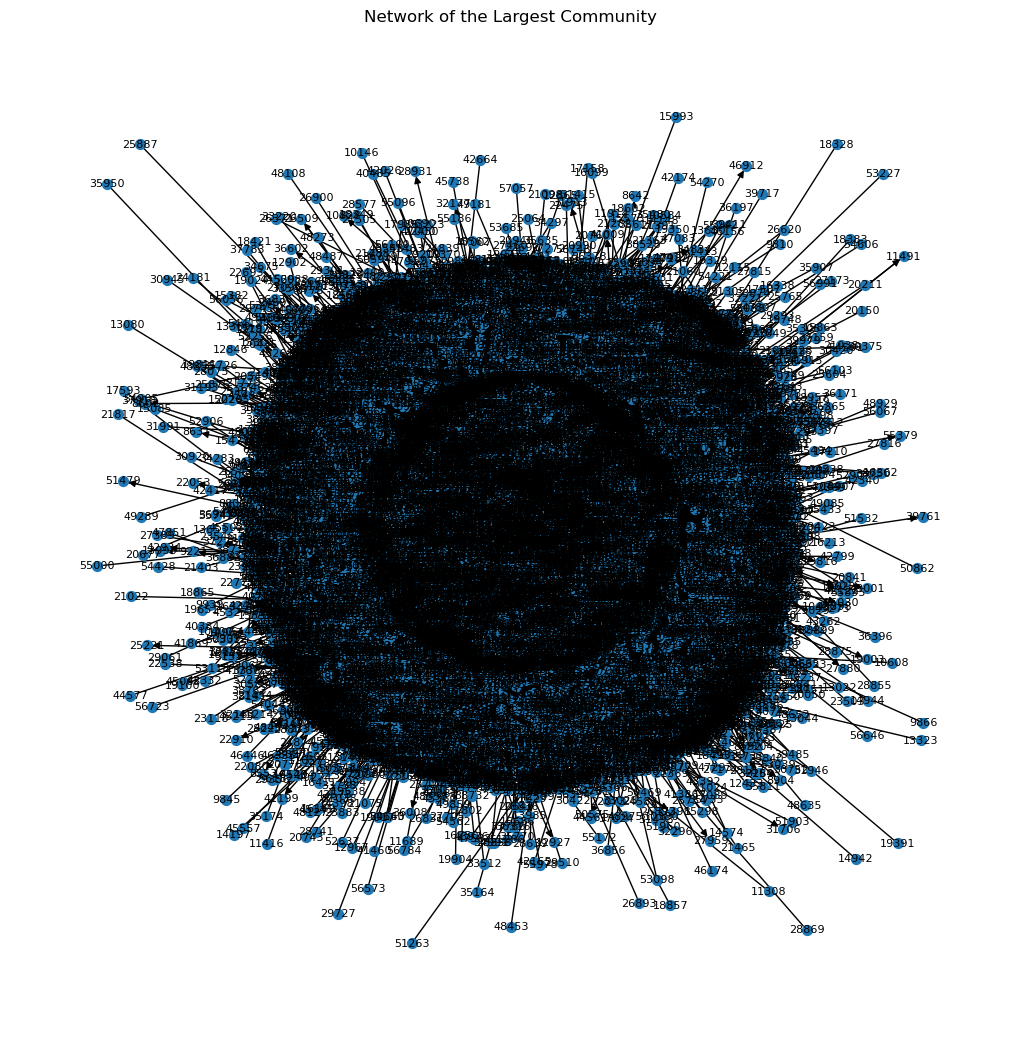

In [10]:
# Visualize the largest community
largest_community = max(communities, key=len)
subgraph = G_main.subgraph(largest_community)
plt.figure(figsize=(10, 10))
nx.draw(subgraph, with_labels=True, node_size=50, font_size=8)
plt.title("Network of the Largest Community")
plt.show()

Visualize the detected communities using different colors for clusters.

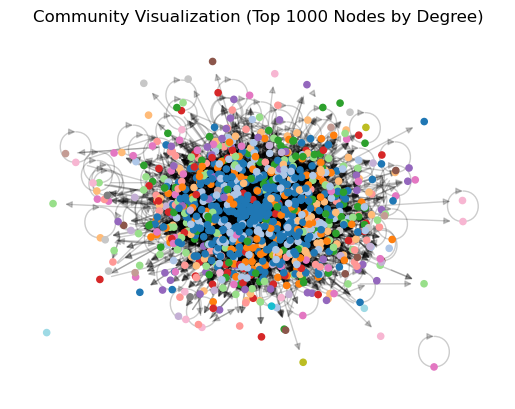

In [11]:
# Select a readable subset (top 1000 nodes by degree)
top_nodes = sorted(G_main.degree, key=lambda x: x[1], reverse=True)[:1000]
sub_nodes = [n for n, d in top_nodes]
G_sub = G_main.subgraph(sub_nodes)

# Map each node in the subset to its community
sub_partition = {n: community_dict[n] for n in G_sub.nodes()}

# Compute layout
pos = nx.spring_layout(G_sub, k=0.15, iterations=20)

# Extract community IDs for coloring
community_ids = [sub_partition[n] for n in G_sub.nodes()]

# Draw nodes with colors representing communities
nx.draw_networkx_nodes(
    G_sub,
    pos,
    node_size=20,
    node_color=community_ids,
    cmap='tab20'
)

# Draw edges lightly
nx.draw_networkx_edges(G_sub, pos, alpha=0.2)

plt.title("Community Visualization (Top 1000 Nodes by Degree)")
plt.axis("off")
plt.show()

### Important Observation
The visualization highlights how the top 1,000 highest‑degree nodes organize into distinct clusters, with each color representing a different community detected by the label‑propagation algorithm. The dense center and separated color patches show that even within the network’s core, communication patterns form clear, structurally meaningful groups.

## Influencer Analysis
Identify the top influencers in the network. Degree, PageRank, and Closeness centrality give you three strong and scalable measures that capture activity, global influence, and distance-based reach without the heavy computation of betweenness. Together they provide a balanced view of who is most connected, most influential, and most centrally positioned in the network.

In [12]:
# Degree centrality
degree_centrality = nx.degree_centrality(G_main)
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by degree centrality:", top_degree)

Top 10 nodes by degree centrality: [('32199', 0.1146119280331509), ('11028', 0.0730508978371479), ('13678', 0.021471159057926667), ('11798', 0.020019932509223154), ('13498', 0.014145087685555923), ('180', 0.010735579528963334), ('13027', 0.010508278985190495), ('1335', 0.008724843949434371), ('1965', 0.0077631878027031274), ('1882', 0.0071162554858112004)]


In [13]:
# PageRank centrality
pagerank_centrality = nx.pagerank(G_main)
top_pagerank = sorted(pagerank_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by PageRank centrality:", top_pagerank)

Top 10 nodes by PageRank centrality: [('180', 0.00374533277664693), ('1965', 0.002757569534713511), ('1648', 0.002661764463753276), ('11798', 0.0025200254973883605), ('97', 0.0023017140679135787), ('346', 0.002212966166223911), ('737', 0.0021927574754737533), ('288', 0.002158608147753097), ('364', 0.002096127123136278), ('1350', 0.0020110322634219998)]


In [14]:
# Closeness centrality
closeness_centrality = nx.closeness_centrality(G_main)
top_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by closeness centrality:", top_closeness)

Top 10 nodes by closeness centrality: [('11798', 0.12183798977604672), ('12586', 0.10895947705798094), ('180', 0.1054688418831938), ('196', 0.1032802857984877), ('1763', 0.10263444927805682), ('1018', 0.10241143716991173), ('33', 0.10230285711997643), ('225', 0.1020813002197745), ('257', 0.10187651697931688), ('580', 0.10171728001223769)]


Based on these tests, determine the top influencers in the network (top 3) by combining the rankings from degree, PageRank, and closeness centrality.

In [15]:
# Build a set of only the nodes that appear in any top-10 list
nodes_of_interest = (
    set([n for n, _ in top_degree]) |
    set([n for n, _ in top_pagerank]) |
    set([n for n, _ in top_closeness])
)

# Convert the set to a list when indexing
df_indexed = pd.DataFrame({
    'degree': degree_centrality,
    'pagerank': pagerank_centrality,
    'closeness': closeness_centrality
}).loc[list(nodes_of_interest)]

# Convert each centrality column into ranks (1 = best)
df_ranked = df_indexed.rank(ascending=False, method='min')

# Sum the ranks to get a combined influence score
df_ranked['combined_score'] = df_ranked.sum(axis=1)

# Get the top 3 influencers (lowest combined score)
top_influencers = df_ranked.nsmallest(3, 'combined_score')

print("Top 3 influencers based on combined centrality ranks:")
print(top_influencers)

Top 3 influencers based on combined centrality ranks:
       degree  pagerank  closeness  combined_score
11798     4.0       4.0        1.0             9.0
180       6.0       1.0        3.0            10.0
1965      9.0       2.0       15.0            26.0


### Important Observation: Influencer impact
The combined‑rank method takes the top‑10 lists from degree, PageRank, and closeness centrality and converts each metric into ranks so they contribute equally despite being on different numerical scales. After restricting the pool to nodes that appear in at least one top‑10 list, the summed ranks identify the nodes that are consistently influential across all three measures. Using this approach, nodes 11798, 180, and 1965 emerge as the top influencers because they occupy structurally central positions and maintain extensive direct connections within the network.

The visualization of the network, which includes color‑coded communities, shows more than 3,000 detected clusters. This high number reflects the fragmented and locally sparse nature of the email network, where many nodes have only a few connections and therefore form small, isolated communities. Within this structure, messages often circulate inside tightly knit pockets before reaching other groups, which helps explain how influence can weaken or “get lost” as it moves across community boundaries. Degree centrality reinforces this interpretation: the top influencers stand out because they have far more direct ties than the average node, giving them disproportionate reach in an otherwise sparsely connected environment.

Because these influencers sit at key points where information can cross between communities, targeting them becomes an effective strategy for broad dissemination. Their position increases the likelihood that a message will travel beyond local clusters and reach multiple segments of the network.

## Visualizing the Results
Visualize the network using pyvis, creating an interactive network graph.

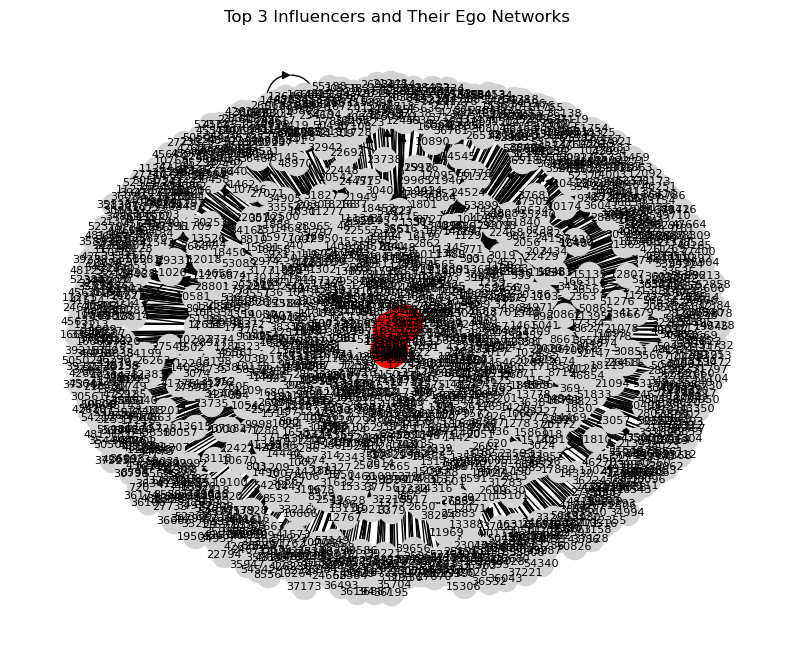

In [ ]:
# top3 must be strings to match G_main
top3 = [str(n) for n in top_influencers.index]

# Build the subgraph
nodes_to_include = set(top3)
for n in top3:
    nodes_to_include.update(G_main.predecessors(n))
    nodes_to_include.update(G_main.successors(n))
G_sub = G_main.subgraph(nodes_to_include)

# Layout
pos = nx.spring_layout(G_sub, seed=42)
plt.figure(figsize=(10, 8))

# Draw all nodes in light gray
nx.draw_networkx_nodes(G_sub, pos, node_color="lightgray", node_size=300)

# Draw top-3 influencers in red and larger
nx.draw_networkx_nodes(G_sub, pos, nodelist=top3, node_color="red", node_size=700)

# Draw edges
nx.draw_networkx_edges(G_sub, pos, arrows=True, arrowstyle="-|>", arrowsize=12)

# Labels
nx.draw_networkx_labels(G_sub, pos, font_size=8)
plt.title("Top 3 Influencers and Their Ego Networks")
plt.axis("off")
plt.show()

## Insights and Discussion
While the email edgelist contains more than fifty thousand unique email addresses as nodes and nearly twice as many edges representing the messages between them, the analysis still supports that the top influencers were identified and classified effectively. While the applied dataset did not contain structural issues or missing values, the number of weakly connected components was relatively small, suggesting a network made up of multiple communities that still maintain some level of interaction with one another. After clustering and identifying those communities within the network, it becomes evident that certain nodes play a pivotal role in maintaining the connectivity and information flow across the network. The visualization above of the largest community supports this statement and shows that a dense core of highly interconnected nodes drives most of the communication within the group, with peripheral nodes linking into that core but rarely to each other. The color‑coded community visual makes the point in a more practical way by showing how the most connected people naturally cluster together. You can see a few tight groups with a ton of overlap in the middle, which lines up with the idea that a small set of highly active nodes keeps the whole network stitched together.

Three different centrality tests were used to rank the most and least influential individuals. Degree, PageRank, and closeness were calculated and converted into ranks to create a fair comparison across metrics. Together, these measures capture how many connections a node has, how important its communication partners are, and how efficiently it can reach others in the network, giving a well‑rounded view of overall influence. Predicting influence is inherently variable because it depends on multiple dynamic factors, but these centrality measures provide a robust framework for identifying key players within the network.

This analysis does not focus on identifying community characteristics; however, the visualization still hints at how different influencers might naturally play different roles in the network, even when slightly cluttered. Some of them sit in the middle of tight little pockets of connections, which makes them great for sparking quick engagement inside their immediate circle. Others sit closer to the edges of multiple clusters, giving them more of a “connector” vibe that helps information jump from one group to another. Even without labeling communities, you can see how each influencer would shape the flow of a campaign in their own way.

Assuming this analysis were being used to help launch a social media campaign, the insights here could guide how to target key influencers to maximize reach and engagement. With thousands of nodes and each influencer occupying a different spot in the network, understanding their roles makes it easier to shape messages that actually travel. The top influencers can kick off the outreach because they sit at the center of the biggest ego networks, while the other high‑reach nodes can act as connectors who help the message jump into groups that might otherwise stay isolated. Together, they can create an impact on both the core and the more niche parts of the network.

In [18]:
!jupyter nbconvert --to pdf DSC515_TJohnson_SMNetworks.ipynb

[NbConvertApp] Converting notebook DSC515_TJohnson_SMNetworks.ipynb to pdf
[NbConvertApp] Support files will be in DSC515_TJohnson_SMNetworks_files\
[NbConvertApp] Making directory .\DSC515_TJohnson_SMNetworks_files
[NbConvertApp] Writing 56201 bytes to notebook.tex
[NbConvertApp] Building PDF
Traceback (most recent call last):
  File "C:\Users\tdjoh\anaconda3\Scripts\jupyter-nbconvert-script.py", line 10, in <module>
    sys.exit(main())
             ~~~~^^
  File "c:\Program Files\Positron\resources\app\extensions\positron-python\python_files\lib\ipykernel\py3\jupyter_core\application.py", line 284, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
    ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Positron\resources\app\extensions\positron-python\python_files\lib\ipykernel\py3\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
    ~~~~~~~~~^^
  File "C:\Users\tdjoh\anaconda3\Lib\site-packages\nbconvert\nbconvertap

## References
Ebel, H., Mielsch, L. I., & Bornholdt, S. (2002). Scale-free topology of e-mail networks. Physical review E, 66(3), 035103

Microsoft. (2024). Copilot [Large language model]. Microsoft. https://copilot.microsoft.com [^1]: Copilot was used only for debugging code and refining wording; all analysis and modeling were performed independently.

NetworkX Developers. (2025). Ego graph. NetworkX 3.6.1 documentation. https://networkx.org/documentation/stable/auto_examples/drawing/plot_ego_graph.html 